# Notebook 08 — Model Evaluation & Cross-Model Comparison
**CMPE-255 | Mental Health & Crisis Signal Mining on Social Media**  
**Owner: Gunanidhi Ramakrishnan**  
**Environment: Google Colab**

---

### What this notebook does

| Experiment | Model | Source |
|---|---|---|
| **EXP-1** | Logistic Regression | metrics.csv from NB-04 |
| **EXP-2** | Linear SVM | metrics.csv from NB-04 |
| **EXP-3** | XGBoost (Bayesian-tuned) | metrics.csv from NB-05 |
| **EXP-4** | DistilBERT fine-tuned with LoRA | Evaluated here |

This notebook:
1. **Evaluates EXP-4** (DistilBERT + LoRA) on the held-out test set
2. **Loads all prior experiment results** from `metrics.csv`
3. **Compares all 4 model families** side by side (tables, bar charts, heatmaps)
4. **Per-class analysis**: identifies which classes each model excels at
5. **Statistical significance**: McNemar's test between top models
6. **Final recommendation** for deployment

---

### Dataset
7-class Sarkar mental health dataset:  
`['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']`

---

### Prerequisites
- Run NB-02, NB-03, NB-04, NB-05, and NB-06 first
- `results/metrics.csv` should contain EXP-1, EXP-2, EXP-3 rows
- `models/xgb_best.joblib` should exist
- `data/test.parquet` should exist
- HuggingFace model `NathanSJSU01/distilBERT_mentalhealth_detection` must be accessible

## 0. Package Installation

In [1]:
# ============================================================
# CELL 1 — Package Installation
# ------------------------------------------------------------
# Install packages required for DistilBERT + LoRA inference
# and model comparison analysis.
# ============================================================
!pip install transformers datasets accelerate evaluate peft --quiet
!pip install "torchao>=0.16.0" --quiet
!pip install scikit-learn matplotlib seaborn pandas numpy --quiet
print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 73.7 MB/s eta 0:00:00
All packages installed.


## 1. Mount Google Drive & Configure Paths

In [2]:
# ============================================================
# CELL 2 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('Drive mounted at /content/drive')

Mounted at /content/drive
Drive mounted at /content/drive


In [3]:
# ============================================================
# CELL 3 — Project Path Configuration
# ============================================================
from pathlib import Path

# --- EDIT THIS LINE if your folder is named differently ---
DRIVE_ROOT = Path('/content/drive/MyDrive/Guna_CMPE255_Project_Final')
# ----------------------------------------------------------

# Sub-directories
DATA_DIR      = DRIVE_ROOT / 'data'
ARTIFACTS_DIR = DRIVE_ROOT / 'artifacts'
MODELS_DIR    = DRIVE_ROOT / 'models'
RESULTS_DIR   = DRIVE_ROOT / 'results'
FIGURES_DIR   = DRIVE_ROOT / 'figures'

# Create output directories if they don't exist yet
for d in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Verify key input files
expected_inputs = [
    DATA_DIR / 'test.parquet',
    MODELS_DIR / 'xgb_best.joblib',
    ARTIFACTS_DIR / 'X_test_tfidf.npz',
    ARTIFACTS_DIR / 'X_test_engineered.npz',
]

print('Input file check:')
all_found = True
for p in expected_inputs:
    status = 'OK' if p.exists() else 'MISSING'
    print(f'  [{status}]  {p.name}')
    if not p.exists():
        all_found = False

# Optional files
optional = [RESULTS_DIR / 'metrics.csv', ARTIFACTS_DIR / 'lda_topic_features.npz']
print('\nOptional files:')
for p in optional:
    status = 'OK' if p.exists() else 'not yet'
    print(f'  [{status}]  {p.name}')

if all_found:
    print('\nAll required files found. Ready to run.')
else:
    print('\nWARNING: Some required files are missing.')
    print('Please run prior notebooks first.')

Input file check:
  [OK]  test.parquet
  [OK]  xgb_best.joblib
  [OK]  X_test_tfidf.npz
  [OK]  X_test_engineered.npz

Optional files:
  [OK]  metrics.csv
  [OK]  lda_topic_features.npz

All required files found. Ready to run.


## 2. Imports & Project Constants

In [4]:
# ============================================================
# CELL 4 — Standard Library Imports
# ============================================================
import random
import os
import json
from datetime import datetime

import numpy as np
import pandas as pd
import scipy.sparse
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import joblib
import warnings

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer,
    DistilBertForSequenceClassification,
    DataCollatorWithPadding,
)
from peft import PeftModel
from datasets import Dataset

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, auc,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('All imports successful.')

All imports successful.


In [5]:
# ============================================================
# CELL 5 — Project Constants
# ============================================================

RANDOM_SEED = 42

def seed_everything(seed=RANDOM_SEED):
    """Set random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

# ---- 7-class Sarkar dataset label map (alphabetically sorted) ----
CLASS_NAMES = ['Anxiety', 'Bipolar', 'Depression', 'Normal',
               'Personality disorder', 'Stress', 'Suicidal']
LABEL_TO_INT = {name: i for i, name in enumerate(CLASS_NAMES)}
LABEL_MAP = {i: name for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

# Consistent colour palette for all plots
CLASS_COLORS = {
    'Anxiety':              '#2ECC71',
    'Bipolar':              '#9B59B6',
    'Depression':           '#3498DB',
    'Normal':               '#95A5A6',
    'Personality disorder': '#E67E22',
    'Stress':               '#E74C3C',
    'Suicidal':             '#2C3E50',
}

print(f'RANDOM_SEED = {RANDOM_SEED}')
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

RANDOM_SEED = 42
Classes (7): ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


## 3. Helper Functions

In [6]:
# ============================================================
# CELL 6 — compute_metrics() Helper
# ------------------------------------------------------------
# Same metric computation used in NB-04 and NB-05.
# Primary metric: macro-averaged F1 (treats all 7 classes equally).
# ============================================================

def compute_metrics(y_true, y_pred, y_proba=None, label_names=None):
    """
    Compute the standard metric suite used across all experiments.

    Parameters
    ----------
    y_true      : 1-D array of true integer class labels
    y_pred      : 1-D array of predicted integer class labels
    y_proba     : 2-D array of predicted probabilities, shape (n_samples, 7)
                  Required for ROC-AUC; set to None if not available.
    label_names : list of class name strings (defaults to CLASS_NAMES)

    Returns
    -------
    dict with keys: macro_f1, weighted_f1, accuracy, roc_auc_macro,
                    per_class_precision, per_class_recall, per_class_f1,
                    confusion_matrix, classification_report
    """
    if label_names is None:
        label_names = CLASS_NAMES

    n_classes = len(label_names)

    macro_f1    = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    acc         = accuracy_score(y_true, y_pred)

    per_class_precision = precision_score(y_true, y_pred, average=None, zero_division=0).tolist()
    per_class_recall    = recall_score   (y_true, y_pred, average=None, zero_division=0).tolist()
    per_class_f1        = f1_score       (y_true, y_pred, average=None, zero_division=0).tolist()

    roc_auc = None
    if y_proba is not None:
        try:
            y_bin   = label_binarize(y_true, classes=list(range(n_classes)))
            roc_auc = roc_auc_score(y_bin, y_proba, average='macro', multi_class='ovr')
        except Exception:
            roc_auc = None

    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    report_str = classification_report(y_true, y_pred, target_names=label_names, zero_division=0)

    return {
        'macro_f1':              round(macro_f1,    4),
        'weighted_f1':           round(weighted_f1, 4),
        'accuracy':              round(acc,         4),
        'roc_auc_macro':         round(roc_auc, 4) if roc_auc is not None else None,
        'per_class_precision':   per_class_precision,
        'per_class_recall':      per_class_recall,
        'per_class_f1':          per_class_f1,
        'confusion_matrix':      cm.tolist(),
        'classification_report': report_str,
    }

print('compute_metrics() ready.')

compute_metrics() ready.


In [7]:
# ============================================================
# CELL 7 — save_metrics() Helper
# ============================================================

METRICS_CSV = RESULTS_DIR / 'metrics.csv'

def save_metrics(exp_name, model, condition, metrics_dict,
                 split='in_dist_test', best_cv_score=None, notes=''):
    """
    Append one row to results/metrics.csv.
    All experiments share the same CSV for cross-notebook comparison.
    """
    row = {
        'exp_name':      exp_name,
        'model':         model,
        'condition':     condition,
        'split':         split,
        'macro_f1':      metrics_dict.get('macro_f1'),
        'weighted_f1':   metrics_dict.get('weighted_f1'),
        'roc_auc_macro': metrics_dict.get('roc_auc_macro'),
        'accuracy':      metrics_dict.get('accuracy'),
        'best_cv_score': best_cv_score,
        'run_timestamp': datetime.utcnow().isoformat(timespec='seconds'),
        'notes':         notes,
    }

    row_df = pd.DataFrame([row])

    if METRICS_CSV.exists():
        existing = pd.read_csv(METRICS_CSV)
        updated  = pd.concat([existing, row_df], ignore_index=True)
    else:
        updated = row_df

    updated.to_csv(METRICS_CSV, index=False)
    print(f'  [saved] {exp_name} | {model} | {condition} | macro_f1={row["macro_f1"]:.4f}')

print('save_metrics() ready.')

save_metrics() ready.


In [8]:
# ============================================================
# CELL 8 — Plotting Helpers
# ============================================================

def plot_confusion_matrix(cm, labels, title='Confusion Matrix',
                          save_path=None, figsize=(8, 6), cmap='Blues'):
    """
    Plot a row-normalised confusion matrix heatmap.

    Row normalisation divides each cell by the row sum, converting
    raw counts to recall fractions. This makes it easy to compare
    confusion patterns across classes with different support.
    """
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        linewidths=0.5,
        vmin=0,
        vmax=1,
    )
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label',      fontsize=11)
    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  [saved] {save_path}')
    plt.show()
    plt.close(fig)


def plot_roc_curves(y_true, y_proba, labels,
                    title='ROC Curves (one-vs-rest)',
                    save_path=None, figsize=(8, 6)):
    """
    Plot one-vs-rest ROC curves for each of the seven classes.
    """
    n_classes  = len(labels)
    y_bin      = label_binarize(y_true, classes=list(range(n_classes)))
    color_vals = list(CLASS_COLORS.values())

    fig, ax = plt.subplots(figsize=figsize)
    for i, name in enumerate(labels):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        auc_val     = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=1.8,
                color=color_vals[i % len(color_vals)],
                label=f'{name}  (AUC = {auc_val:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random baseline')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate',  fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  [saved] {save_path}')
    plt.show()
    plt.close(fig)

print('Plotting helpers ready.')

Plotting helpers ready.


## 4. Load Test Data

In [9]:
# ============================================================
# CELL 9 — Load Test Data
# ------------------------------------------------------------
# The test parquet has columns:
#   'statement' — raw text of the social media post
#   'label'     — string class name (one of 7 classes)
# ============================================================

test_df = pd.read_parquet(DATA_DIR / 'test.parquet')

# Encode string labels to integers (alphabetically sorted)
y_test = test_df['label'].map(LABEL_TO_INT).values

print(f'Test samples: {len(test_df)}')
print(f'Columns: {list(test_df.columns)}')
print(f'\nClass distribution (test set):')
print(test_df['label'].value_counts().sort_index())
print(f'\nSample statement: "{test_df["statement"].iloc[0][:100]}..."')

Test samples: 10537
Columns: ['statement', 'label']

Class distribution (test set):
label
Anxiety                  768
Bipolar                  556
Depression              3081
Normal                  3269
Personality disorder     215
Stress                   517
Suicidal                2131
Name: count, dtype: int64

Sample statement: "I left a mildly suicidal message on a dyslexia website , someone contacted the police to do a welfar..."


In [10]:
# ============================================================
# CELL 9b — Remove stale EXP-4 row from previous broken run
# ------------------------------------------------------------
# Run this once to clean up the old DistilBERT result (0.49)
# that was recorded before the NB-06 fix.
# ============================================================

if METRICS_CSV.exists():
    df = pd.read_csv(METRICS_CSV)
    old_count = len(df)
    df = df[df['exp_name'] != 'EXP-4']
    df.to_csv(METRICS_CSV, index=False)
    removed = old_count - len(df)
    if removed > 0:
        print(f'Removed {removed} old EXP-4 row(s). Remaining: {len(df)} rows')
    else:
        print(f'No old EXP-4 rows found. metrics.csv has {len(df)} rows.')
else:
    print('metrics.csv not found yet — will be created when EXP-4 is saved.')

Removed 1 old EXP-4 row(s). Remaining: 12 rows


---

## 5. EXP-4 — DistilBERT + LoRA Evaluation

We evaluate the fine-tuned DistilBERT model from HuggingFace:
`NathanSJSU01/distilBERT_mentalhealth_detection`

This model was fine-tuned using LoRA (Low-Rank Adaptation) adapters on
top of `distilbert-base-uncased`. LoRA keeps the base model frozen and
only trains small rank-decomposition matrices, making training efficient
while preserving the pretrained representations.

### Inference Pipeline
1. Load base model (`distilbert-base-uncased`) with 7-class classification head
2. Apply LoRA adapters from HuggingFace
3. Tokenize test data with truncation at 512 tokens
4. Run batched inference (batch_size=32) with DataCollatorWithPadding
5. Collect logits, convert to probabilities via softmax
6. Compute full metric suite

In [11]:
# ============================================================
# CELL 10 — Load DistilBERT + LoRA Model
# ------------------------------------------------------------
# Try loading from HuggingFace Hub first (canonical source).
# Fall back to Google Drive if Hub is unreachable or model
# not found (e.g., offline Colab session).
# ============================================================

# Determine device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Model source paths
HF_REPO = 'NathanSJSU01/distilBERT_mentalhealth_detection'
DRIVE_LORA_PATH = MODELS_DIR / 'distilbert_lora'

model = None
source_used = None

# --- Attempt 1: Load from HuggingFace Hub ---
try:
    print(f'Attempting to load from HuggingFace Hub: {HF_REPO}')

    # Load tokenizer from HF repo
    tokenizer = AutoTokenizer.from_pretrained(HF_REPO)

    # Load base model with 7-class classification head
    base_model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=NUM_CLASSES,
    )

    # Apply LoRA adapters from HF Hub
    model = PeftModel.from_pretrained(base_model, HF_REPO)
    source_used = 'HuggingFace Hub'
    print(f'Successfully loaded from HuggingFace Hub.')

except Exception as e:
    print(f'HuggingFace Hub load failed: {e}')
    print(f'Falling back to Google Drive...')

# --- Attempt 2: Fall back to Google Drive ---
if model is None:
    if DRIVE_LORA_PATH.exists():
        print(f'Loading from Google Drive: {DRIVE_LORA_PATH}')

        # Load tokenizer (Drive copy or base)
        drive_tokenizer_path = DRIVE_LORA_PATH
        tokenizer = AutoTokenizer.from_pretrained(
            str(drive_tokenizer_path) if (drive_tokenizer_path / 'tokenizer_config.json').exists()
            else 'distilbert-base-uncased'
        )

        # Load base model
        base_model = DistilBertForSequenceClassification.from_pretrained(
            'distilbert-base-uncased',
            num_labels=NUM_CLASSES,
        )

        # Apply LoRA adapters from Drive
        model = PeftModel.from_pretrained(base_model, str(DRIVE_LORA_PATH))
        source_used = 'Google Drive'
        print(f'Successfully loaded from Google Drive.')
    else:
        raise FileNotFoundError(
            f'Model not found on HuggingFace Hub ({HF_REPO}) or '
            f'Google Drive ({DRIVE_LORA_PATH}). Run NB-06 first.'
        )

# --- Set to eval mode and move to device ---
model.eval()
model.to(device)

print(f'\nModel loaded successfully from: {source_used}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

Using device: cuda
Attempting to load from HuggingFace Hub: NathanSJSU01/distilBERT_mentalhealth_detection


tokenizer_config.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


adapter_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/4.75M [00:00<?, ?B/s]

Successfully loaded from HuggingFace Hub.

Model loaded successfully from: HuggingFace Hub
Trainable parameters: 0
Total parameters: 68,144,654


In [12]:
# ============================================================
# CELL 11 — Tokenize Test Data and Create DataLoader
# ============================================================

# Convert test dataframe to HuggingFace Dataset
hf_dataset = Dataset.from_pandas(test_df[['statement', 'label']].copy())

# Map string labels to integers
hf_dataset = hf_dataset.map(
    lambda x: {'labels': LABEL_TO_INT[x['label']]},
    remove_columns=['label'],
)

# Tokenize using the 'statement' column
def tokenize_fn(examples):
    return tokenizer(
        examples['statement'],
        truncation=True,
        max_length=512,
    )

hf_dataset = hf_dataset.map(tokenize_fn, batched=True)

# Remove the raw text column (model only needs input_ids, attention_mask, labels)
hf_dataset = hf_dataset.remove_columns(['statement'])

# NOTE: We do NOT call hf_dataset.set_format('torch') here because it triggers
# a torchvision VideoReader import bug in Colab. DataCollatorWithPadding handles
# the conversion to PyTorch tensors automatically during batching.

# Create DataLoader with DataCollatorWithPadding for efficient batching
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

test_dataloader = DataLoader(
    hf_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=data_collator,
)

print(f'Dataset tokenized: {len(hf_dataset)} samples')
print(f'Number of batches: {len(test_dataloader)}')

# Verify a batch
sample_batch = next(iter(test_dataloader))
print(f'Sample batch shapes: {({k: v.shape for k, v in sample_batch.items()})}')

Map:   0%|          | 0/10537 [00:00<?, ? examples/s]

Map:   0%|          | 0/10537 [00:00<?, ? examples/s]

Dataset tokenized: 10537 samples
Number of batches: 330
Sample batch shapes: {'labels': torch.Size([32]), 'input_ids': torch.Size([32, 512]), 'attention_mask': torch.Size([32, 512])}


In [13]:
# ============================================================
# CELL 12 — Run DistilBERT Inference
# ------------------------------------------------------------
# Batched inference with torch.no_grad() for memory efficiency.
# We collect both predictions and logits (for softmax -> probabilities).
# ============================================================

all_predictions = []
all_logits = []
all_labels = []

print('Running DistilBERT inference...')

with torch.no_grad():
    for batch_idx, batch in enumerate(test_dataloader):
        # Move batch to device
        batch = {k: v.to(device) for k, v in batch.items()}

        # Forward pass
        outputs = model(**batch)
        logits = outputs.logits

        # Get predictions
        predictions = torch.argmax(logits, dim=-1)

        # Collect results
        all_predictions.extend(predictions.cpu().numpy())
        all_logits.append(logits.cpu())
        all_labels.extend(batch['labels'].cpu().numpy())

        if (batch_idx + 1) % 10 == 0:
            print(f'  Processed batch {batch_idx + 1}/{len(test_dataloader)}')

# Convert to numpy arrays
y_pred_bert = np.array(all_predictions)
y_true_bert = np.array(all_labels)

# Convert logits to probabilities via softmax
all_logits_tensor = torch.cat(all_logits, dim=0)
y_proba_bert = F.softmax(all_logits_tensor, dim=-1).numpy()

print(f'\nInference complete.')
print(f'Predictions shape: {y_pred_bert.shape}')
print(f'Probabilities shape: {y_proba_bert.shape}')

# Sanity check: labels should match
assert np.array_equal(y_true_bert, y_test), 'Label mismatch between DataLoader and test_df!'
print('Label consistency check passed.')

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Running DistilBERT inference...
  Processed batch 10/330
  Processed batch 20/330
  Processed batch 30/330
  Processed batch 40/330
  Processed batch 50/330
  Processed batch 60/330
  Processed batch 70/330
  Processed batch 80/330
  Processed batch 90/330
  Processed batch 100/330
  Processed batch 110/330
  Processed batch 120/330
  Processed batch 130/330
  Processed batch 140/330
  Processed batch 150/330
  Processed batch 160/330
  Processed batch 170/330
  Processed batch 180/330
  Processed batch 190/330
  Processed batch 200/330
  Processed batch 210/330
  Processed batch 220/330
  Processed batch 230/330
  Processed batch 240/330
  Processed batch 250/330
  Processed batch 260/330
  Processed batch 270/330
  Processed batch 280/330
  Processed batch 290/330
  Processed batch 300/330
  Processed batch 310/330
  Processed batch 320/330
  Processed batch 330/330

Inference complete.
Predictions shape: (10537,)
Probabilities shape: (10537, 7)
Label consistency check passed.


In [14]:
# ============================================================
# CELL 13 — Compute DistilBERT Metrics
# ============================================================

metrics_bert = compute_metrics(y_test, y_pred_bert, y_proba_bert)

print('EXP-4 DistilBERT + LoRA — Test Set Results')
print('=' * 60)
print(f'  Macro-F1      : {metrics_bert["macro_f1"]:.4f}')
print(f'  Weighted-F1   : {metrics_bert["weighted_f1"]:.4f}')
print(f'  Accuracy      : {metrics_bert["accuracy"]:.4f}')
print(f'  ROC-AUC (macro): {metrics_bert["roc_auc_macro"]:.4f}')
print('=' * 60)
print()
print(metrics_bert['classification_report'])

EXP-4 DistilBERT + LoRA — Test Set Results
  Macro-F1      : 0.7139
  Weighted-F1   : 0.7617
  Accuracy      : 0.7578
  ROC-AUC (macro): 0.9628

                      precision    recall  f1-score   support

             Anxiety       0.76      0.82      0.79       768
             Bipolar       0.71      0.81      0.76       556
          Depression       0.82      0.60      0.69      3081
              Normal       0.93      0.87      0.90      3269
Personality disorder       0.42      0.79      0.55       215
              Stress       0.51      0.76      0.61       517
            Suicidal       0.64      0.77      0.70      2131

            accuracy                           0.76     10537
           macro avg       0.68      0.77      0.71     10537
        weighted avg       0.78      0.76      0.76     10537



In [15]:
# ============================================================
# CELL 14 — Save DistilBERT Metrics to metrics.csv
# ============================================================

save_metrics(
    exp_name='EXP-4',
    model='DistilBERT-LoRA',
    condition='finetuned',
    metrics_dict=metrics_bert,
    split='in_dist_test',
    best_cv_score=None,
    notes='distilbert-base-uncased + LoRA from NathanSJSU01/distilBERT_mentalhealth_detection',
)

print('\nEXP-4 metrics saved to metrics.csv')

  [saved] EXP-4 | DistilBERT-LoRA | finetuned | macro_f1=0.7139

EXP-4 metrics saved to metrics.csv


  [saved] /content/drive/MyDrive/Guna_CMPE255_Project_Final/figures/cm_distilbert_lora.png


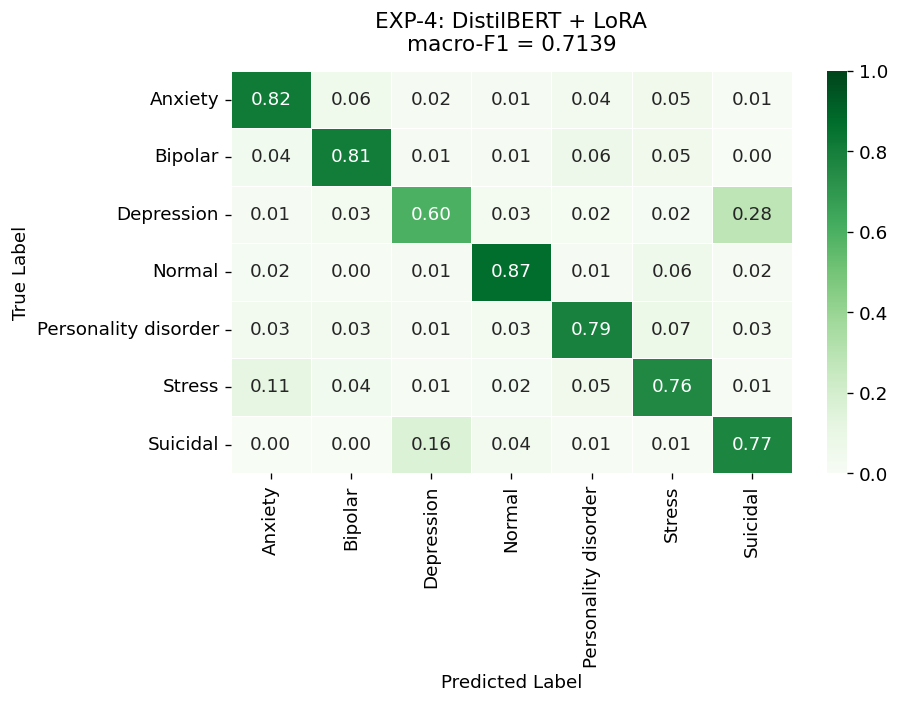

In [16]:
# ============================================================
# CELL 15 — DistilBERT Confusion Matrix
# ============================================================

cm_bert = np.array(metrics_bert['confusion_matrix'])

plot_confusion_matrix(
    cm_bert,
    CLASS_NAMES,
    title=f'EXP-4: DistilBERT + LoRA\nmacro-F1 = {metrics_bert["macro_f1"]:.4f}',
    save_path=FIGURES_DIR / 'cm_distilbert_lora.png',
    cmap='Greens',
)

  [saved] /content/drive/MyDrive/Guna_CMPE255_Project_Final/figures/roc_distilbert_lora.png


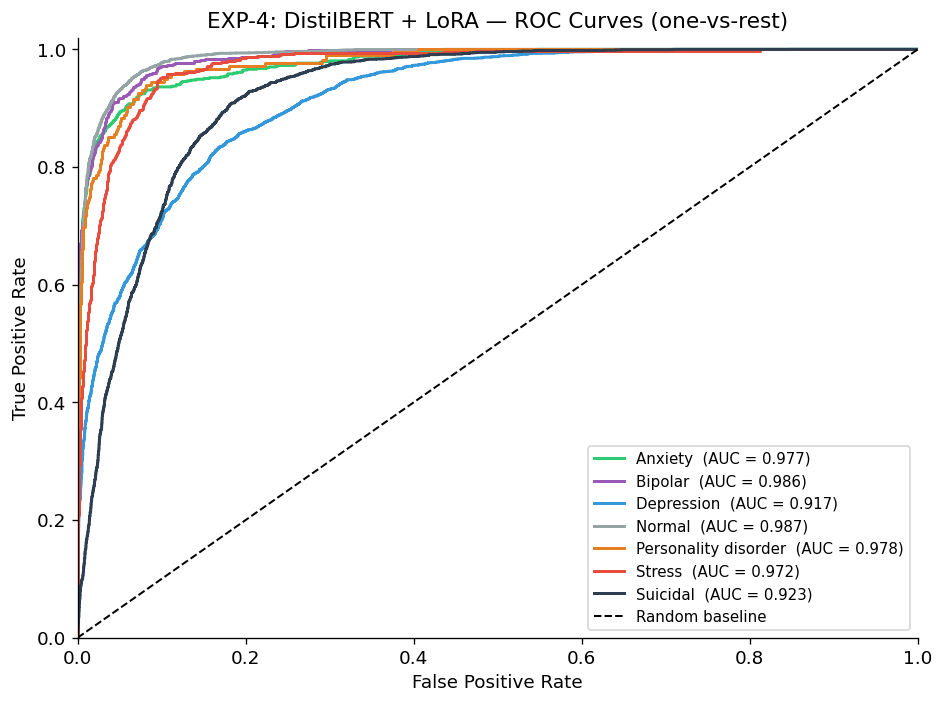

In [17]:
# ============================================================
# CELL 16 — DistilBERT ROC Curves
# ============================================================

plot_roc_curves(
    y_test,
    y_proba_bert,
    CLASS_NAMES,
    title='EXP-4: DistilBERT + LoRA — ROC Curves (one-vs-rest)',
    save_path=FIGURES_DIR / 'roc_distilbert_lora.png',
)

---

## 6. Load All Prior Results from metrics.csv

Now we load `metrics.csv` which should contain results from:
- **EXP-1**: Logistic Regression (3 conditions from NB-04)
- **EXP-2**: Linear SVM (3 conditions from NB-04)
- **EXP-3**: XGBoost (baseline + tuned from NB-05)
- **EXP-4**: DistilBERT-LoRA (just saved above)
- **LP-Probe**: Leakage probe (from NB-04)

We select the **best condition per model family** (highest macro_f1) for comparison.

In [19]:
# ============================================================
# CELL 17 — Load metrics.csv and Select Best Conditions
# ============================================================

if METRICS_CSV.exists():
    all_metrics = pd.read_csv(METRICS_CSV)
    print(f'Loaded metrics.csv: {len(all_metrics)} rows')
    print(f'Experiments found: {all_metrics["exp_name"].unique().tolist()}')

    # Remove duplicate rows (e.g., from re-running prior notebooks)
    all_metrics = all_metrics.drop_duplicates(
        subset=['exp_name', 'model', 'condition'], keep='last'
    )
    print(f'After dedup: {len(all_metrics)} rows')

    print()
    print(all_metrics[['exp_name', 'model', 'condition', 'macro_f1', 'weighted_f1',
                       'roc_auc_macro', 'accuracy']].to_string(index=False))
else:
    print('WARNING: metrics.csv not found.')
    print('Only EXP-4 (DistilBERT) results are available.')
    # Create a minimal dataframe with just EXP-4
    all_metrics = pd.DataFrame([{
        'exp_name': 'EXP-4',
        'model': 'DistilBERT-LoRA',
        'condition': 'finetuned',
        'macro_f1': metrics_bert['macro_f1'],
        'weighted_f1': metrics_bert['weighted_f1'],
        'roc_auc_macro': metrics_bert['roc_auc_macro'],
        'accuracy': metrics_bert['accuracy'],
    }])

Loaded metrics.csv: 13 rows
Experiments found: ['EXP-1', 'EXP-2', 'LP-Probe', 'EXP-3', 'EXP-4']
After dedup: 11 rows

exp_name              model            condition  macro_f1  weighted_f1  roc_auc_macro  accuracy
   EXP-1 LogisticRegression         no_balancing    0.6740       0.7242         0.9466    0.7223
   EXP-1 LogisticRegression       class_weighted    0.6740       0.7242         0.9466    0.7223
   EXP-1 LogisticRegression                smote    0.6740       0.7242         0.9466    0.7223
   EXP-2          LinearSVM         no_balancing    0.6605       0.7141         0.9419    0.7129
   EXP-2          LinearSVM       class_weighted    0.6605       0.7141         0.9419    0.7129
   EXP-2          LinearSVM                smote    0.6605       0.7141         0.9419    0.7129
LP-Probe LogisticRegression         no_balancing    0.3049       0.4681         0.7759    0.4854
   EXP-3            XGBoost     tfidf+engineered    0.6984       0.7462         0.9564    0.7428
   EXP-3 

In [20]:
# ============================================================
# CELL 18 — Select Best Condition Per Model Family
# ------------------------------------------------------------
# For the cross-model comparison, we pick the single best
# condition (highest macro_f1) from each experiment.
# ============================================================

# Filter to only the main experiments (exclude LP-Probe for the comparison chart)
main_exps = all_metrics[all_metrics['exp_name'].isin(['EXP-1', 'EXP-2', 'EXP-3', 'EXP-4'])].copy()

# Select best condition per experiment (highest macro_f1)
best_per_exp = main_exps.loc[main_exps.groupby('exp_name')['macro_f1'].idxmax()].copy()
best_per_exp = best_per_exp.sort_values('macro_f1', ascending=False).reset_index(drop=True)

print('Best Condition Per Model Family (ranked by macro-F1)')
print('=' * 80)
display_cols = ['exp_name', 'model', 'condition', 'macro_f1', 'weighted_f1',
                'roc_auc_macro', 'accuracy']
print(best_per_exp[display_cols].to_string(index=False))

# Store for later use
best_models = best_per_exp.copy()

Best Condition Per Model Family (ranked by macro-F1)
exp_name              model            condition  macro_f1  weighted_f1  roc_auc_macro  accuracy
   EXP-4    DistilBERT-LoRA            finetuned    0.7139       0.7617         0.9628    0.7578
   EXP-3            XGBoost tfidf+engineered+lda    0.7033       0.7500         0.9582    0.7460
   EXP-1 LogisticRegression         no_balancing    0.6740       0.7242         0.9466    0.7223
   EXP-2          LinearSVM         no_balancing    0.6605       0.7141         0.9419    0.7129


---

## 7. Cross-Model Comparison

Visual comparison of all four model families on the same test set.

In [21]:
# ============================================================
# CELL 19 — Formatted Comparison Table
# ============================================================

print('\n' + '=' * 80)
print('CROSS-MODEL COMPARISON — Best Configuration Per Model Family')
print('=' * 80)
print()

comparison_table = best_models[['model', 'condition', 'macro_f1', 'weighted_f1',
                                 'roc_auc_macro', 'accuracy']].copy()
comparison_table.columns = ['Model', 'Condition', 'Macro-F1', 'Weighted-F1',
                            'ROC-AUC (macro)', 'Accuracy']

# Add rank column
comparison_table.insert(0, 'Rank', range(1, len(comparison_table) + 1))

print(comparison_table.to_string(index=False))
print()
print(f'Winner: {comparison_table.iloc[0]["Model"]} ({comparison_table.iloc[0]["Condition"]})')
print(f'  Macro-F1 = {comparison_table.iloc[0]["Macro-F1"]:.4f}')


CROSS-MODEL COMPARISON — Best Configuration Per Model Family

 Rank              Model            Condition  Macro-F1  Weighted-F1  ROC-AUC (macro)  Accuracy
    1    DistilBERT-LoRA            finetuned    0.7139       0.7617           0.9628    0.7578
    2            XGBoost tfidf+engineered+lda    0.7033       0.7500           0.9582    0.7460
    3 LogisticRegression         no_balancing    0.6740       0.7242           0.9466    0.7223
    4          LinearSVM         no_balancing    0.6605       0.7141           0.9419    0.7129

Winner: DistilBERT-LoRA (finetuned)
  Macro-F1 = 0.7139


Saved: /content/drive/MyDrive/Guna_CMPE255_Project_Final/figures/cross_model_macro_f1.png


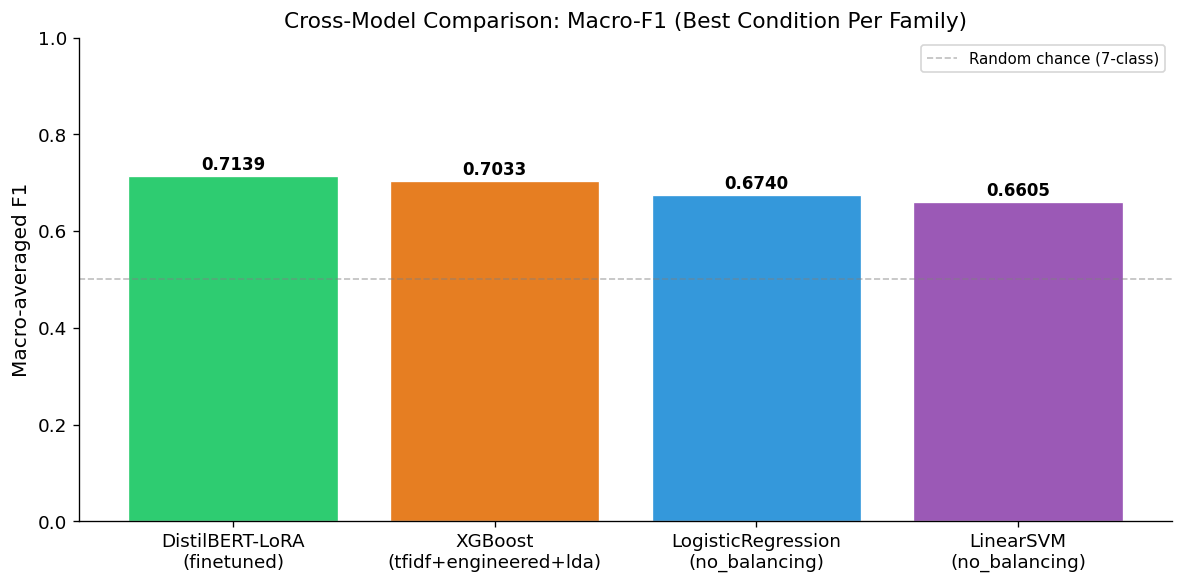

In [22]:
# ============================================================
# CELL 20 — Bar Chart: Macro-F1 Comparison
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

# Build labels
bar_labels = [f'{row["model"]}\n({row["condition"]})' for _, row in best_models.iterrows()]
macro_f1_vals = best_models['macro_f1'].values

# Color coding by model family
model_colors = {
    'LogisticRegression': '#3498DB',
    'LinearSVM':          '#9B59B6',
    'XGBoost':            '#E67E22',
    'DistilBERT-LoRA':    '#2ECC71',
}
colors = [model_colors.get(row['model'], '#888888') for _, row in best_models.iterrows()]

bars = ax.bar(bar_labels, macro_f1_vals, color=colors, edgecolor='white', linewidth=0.8)

# Annotate bars with values
for bar, val in zip(bars, macro_f1_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.0)
ax.set_ylabel('Macro-averaged F1', fontsize=12)
ax.set_title('Cross-Model Comparison: Macro-F1 (Best Condition Per Family)', fontsize=13)
ax.axhline(y=0.5, color='gray', linestyle='--', lw=1, alpha=0.5, label='Random chance (7-class)')
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'cross_model_macro_f1.png', dpi=150, bbox_inches='tight')
print(f'Saved: {FIGURES_DIR / "cross_model_macro_f1.png"}')
plt.show()

Saved: /content/drive/MyDrive/Guna_CMPE255_Project_Final/figures/cross_model_multi_metric.png


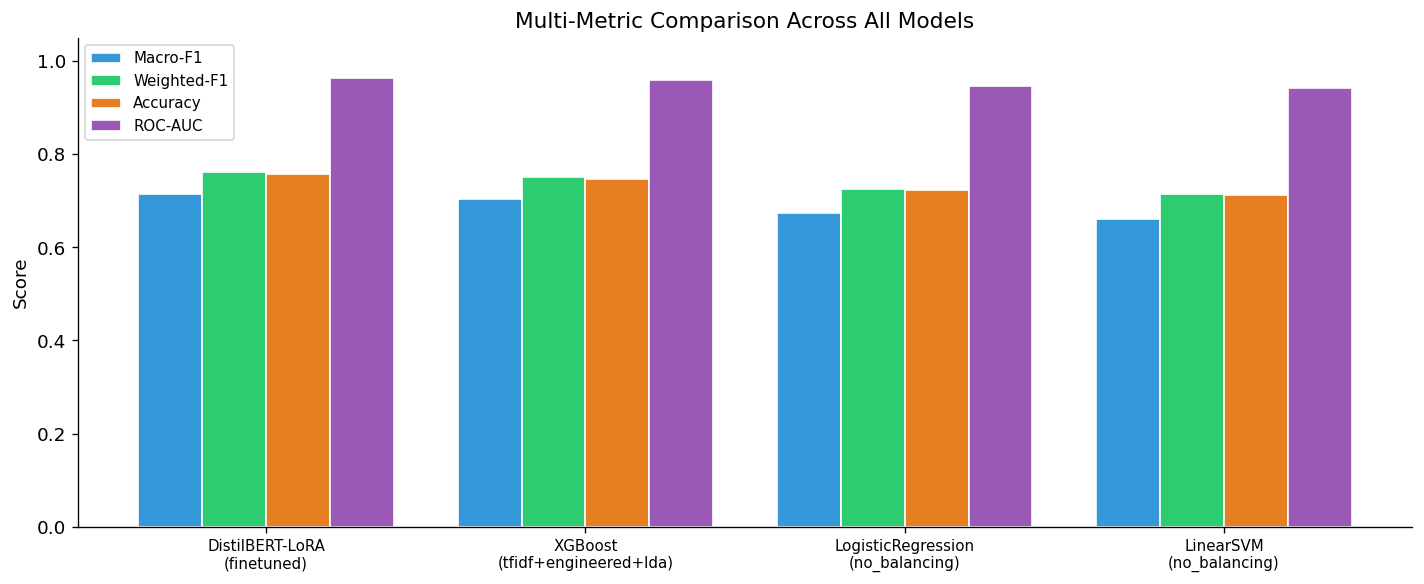

In [23]:
# ============================================================
# CELL 21 — Multi-Metric Grouped Bar Chart
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

metrics_to_plot = ['macro_f1', 'weighted_f1', 'accuracy']
# Only include roc_auc if all models have it
if best_models['roc_auc_macro'].notna().all():
    metrics_to_plot.append('roc_auc_macro')

x = np.arange(len(best_models))
width = 0.8 / len(metrics_to_plot)

metric_colors = ['#3498DB', '#2ECC71', '#E67E22', '#9B59B6']
metric_labels = ['Macro-F1', 'Weighted-F1', 'Accuracy', 'ROC-AUC']

for i, (metric, color, label) in enumerate(zip(metrics_to_plot, metric_colors, metric_labels)):
    vals = best_models[metric].values
    offset = (i - len(metrics_to_plot)/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, color=color, label=label, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([f'{row["model"]}\n({row["condition"]})' for _, row in best_models.iterrows()],
                   fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Multi-Metric Comparison Across All Models', fontsize=13)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'cross_model_multi_metric.png', dpi=150, bbox_inches='tight')
print(f'Saved: {FIGURES_DIR / "cross_model_multi_metric.png"}')
plt.show()

---

## 8. Per-Class Analysis (DistilBERT vs XGBoost)

We compare per-class F1 scores between the two strongest models:
- **DistilBERT + LoRA** (contextual embeddings)
- **XGBoost** (TF-IDF + engineered features)

This reveals which mental health categories benefit most from
contextual understanding vs. lexical/statistical features.

In [24]:
# ============================================================
# CELL 22 — Load XGBoost Model and Generate Predictions
# ============================================================

# Load the best XGBoost model saved by NB-05
xgb_model_path = MODELS_DIR / 'xgb_best.joblib'

if xgb_model_path.exists():
    xgb_model = joblib.load(xgb_model_path)
    print(f'XGBoost model loaded from: {xgb_model_path}')

    # Load test feature matrices (same as NB-05)
    X_test_tfidf = scipy.sparse.load_npz(ARTIFACTS_DIR / 'X_test_tfidf.npz').tocsr()
    X_test_eng   = np.load(ARTIFACTS_DIR / 'X_test_engineered.npz')['arr_0']

    # Check for LDA features
    lda_path = ARTIFACTS_DIR / 'lda_topic_features.npz'
    if lda_path.exists():
        lda_data = np.load(lda_path)
        X_test_lda = lda_data['X_test']
        print(f'LDA features loaded: {X_test_lda.shape[1]} topics')
    else:
        X_test_lda = None
        print('LDA features not found (using TF-IDF + engineered only)')

    # Build combined feature matrix
    parts_test = [X_test_tfidf, scipy.sparse.csr_matrix(X_test_eng)]
    if X_test_lda is not None:
        parts_test.append(scipy.sparse.csr_matrix(X_test_lda))

    X_test_combined = scipy.sparse.hstack(parts_test, format='csr')
    print(f'Combined test feature matrix: {X_test_combined.shape}')

    # Generate XGBoost predictions
    y_pred_xgb  = xgb_model.predict(X_test_combined)
    y_proba_xgb = xgb_model.predict_proba(X_test_combined)

    metrics_xgb = compute_metrics(y_test, y_pred_xgb, y_proba_xgb)
    print(f'\nXGBoost test macro-F1: {metrics_xgb["macro_f1"]:.4f}')

    xgb_loaded = True
else:
    print(f'WARNING: {xgb_model_path} not found.')
    print('Skipping per-class comparison with XGBoost.')
    xgb_loaded = False

XGBoost model loaded from: /content/drive/MyDrive/Guna_CMPE255_Project_Final/models/xgb_best.joblib
LDA features loaded: 18 topics
Combined test feature matrix: (10537, 50033)

XGBoost test macro-F1: 0.7033


In [25]:
# ============================================================
# CELL 23 — Per-Class F1 Comparison: DistilBERT vs XGBoost
# ============================================================

if xgb_loaded:
    # Per-class F1 scores
    bert_per_class_f1 = metrics_bert['per_class_f1']
    xgb_per_class_f1  = metrics_xgb['per_class_f1']

    # Create comparison dataframe
    per_class_comparison = pd.DataFrame({
        'Class': CLASS_NAMES,
        'DistilBERT-LoRA F1': [round(f, 4) for f in bert_per_class_f1],
        'XGBoost F1': [round(f, 4) for f in xgb_per_class_f1],
    })
    per_class_comparison['Difference (BERT - XGB)'] = [
        round(b - x, 4) for b, x in zip(bert_per_class_f1, xgb_per_class_f1)
    ]
    per_class_comparison['Winner'] = [
        'DistilBERT' if b > x else ('XGBoost' if x > b else 'Tie')
        for b, x in zip(bert_per_class_f1, xgb_per_class_f1)
    ]

    print('Per-Class F1 Comparison: DistilBERT-LoRA vs XGBoost')
    print('=' * 75)
    print(per_class_comparison.to_string(index=False))

    # Summary
    bert_wins = (per_class_comparison['Winner'] == 'DistilBERT').sum()
    xgb_wins  = (per_class_comparison['Winner'] == 'XGBoost').sum()
    ties      = (per_class_comparison['Winner'] == 'Tie').sum()
    print(f'\nSummary: DistilBERT wins {bert_wins} classes, XGBoost wins {xgb_wins}, Ties: {ties}')
else:
    print('Skipped: XGBoost model not available for per-class comparison.')

Per-Class F1 Comparison: DistilBERT-LoRA vs XGBoost
               Class  DistilBERT-LoRA F1  XGBoost F1  Difference (BERT - XGB)     Winner
             Anxiety              0.7867      0.7750                   0.0118 DistilBERT
             Bipolar              0.7589      0.7618                  -0.0030    XGBoost
          Depression              0.6931      0.6769                   0.0162 DistilBERT
              Normal              0.9000      0.8921                   0.0079 DistilBERT
Personality disorder              0.5502      0.5209                   0.0292 DistilBERT
              Stress              0.6102      0.6153                  -0.0050    XGBoost
            Suicidal              0.6984      0.6812                   0.0171 DistilBERT

Summary: DistilBERT wins 5 classes, XGBoost wins 2, Ties: 0


Saved: /content/drive/MyDrive/Guna_CMPE255_Project_Final/figures/per_class_f1_bert_vs_xgb.png


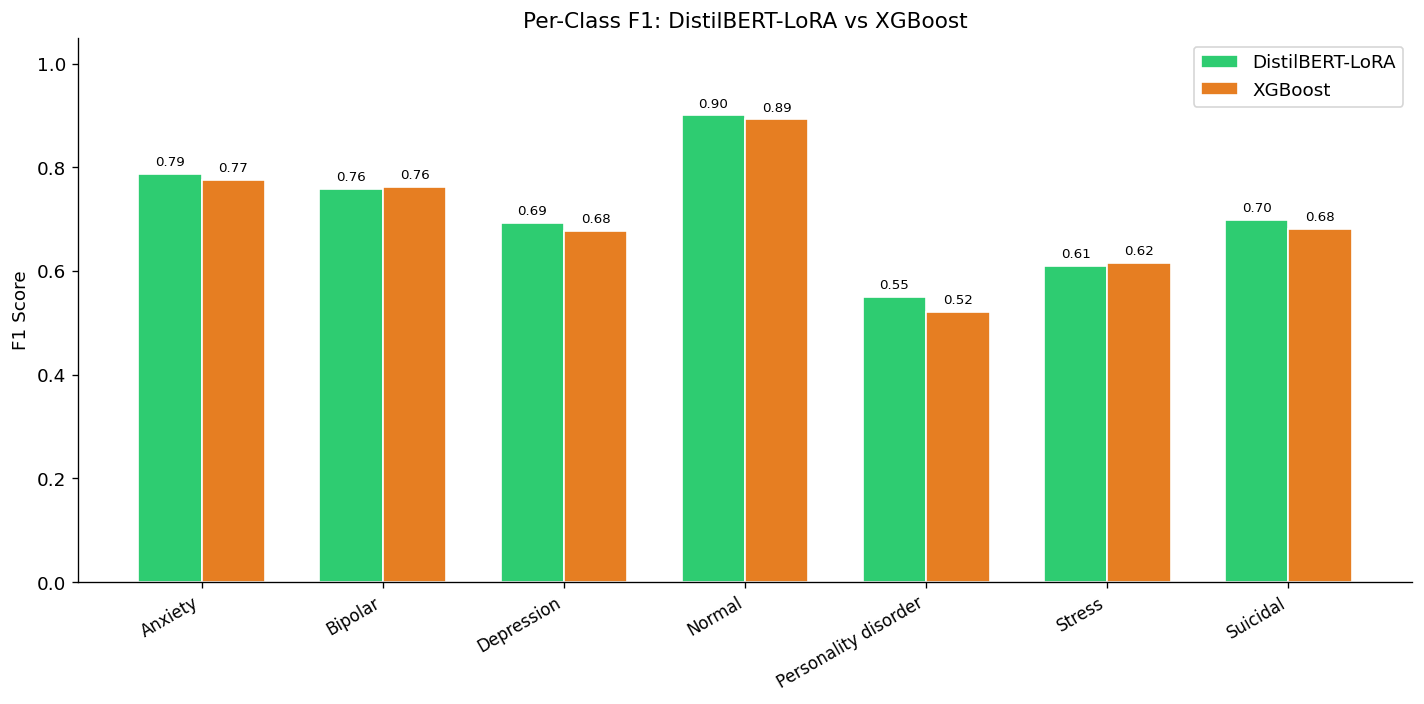

In [26]:
# ============================================================
# CELL 24 — Grouped Bar Chart: Per-Class F1
# ============================================================

if xgb_loaded:
    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(NUM_CLASSES)
    width = 0.35

    bars1 = ax.bar(x - width/2, bert_per_class_f1, width,
                   label='DistilBERT-LoRA', color='#2ECC71', edgecolor='white')
    bars2 = ax.bar(x + width/2, xgb_per_class_f1, width,
                   label='XGBoost', color='#E67E22', edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=10)
    ax.set_ylabel('F1 Score', fontsize=11)
    ax.set_title('Per-Class F1: DistilBERT-LoRA vs XGBoost', fontsize=13)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=11)

    # Add value labels
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'per_class_f1_bert_vs_xgb.png', dpi=150, bbox_inches='tight')
    print(f'Saved: {FIGURES_DIR / "per_class_f1_bert_vs_xgb.png"}')
    plt.show()
else:
    print('Skipped: XGBoost model not available.')

Loaded lr_class_weighted.joblib for per-class F1
Loaded svm_class_weighted.joblib for per-class F1

Per-Class F1 Heatmap Data (4 models):
                      DistilBERT-LoRA  XGBoost  LogisticRegression  LinearSVM
Anxiety                        0.7867   0.7750              0.7492     0.7500
Bipolar                        0.7589   0.7618              0.7385     0.7208
Depression                     0.6931   0.6769              0.6243     0.5902
Normal                         0.9000   0.8921              0.8892     0.8913
Personality disorder           0.5502   0.5209              0.5052     0.4653
Stress                         0.6102   0.6153              0.5425     0.5291
Suicidal                       0.6984   0.6812              0.6692     0.6769

Saved: /content/drive/MyDrive/Guna_CMPE255_Project_Final/figures/per_class_f1_heatmap.png


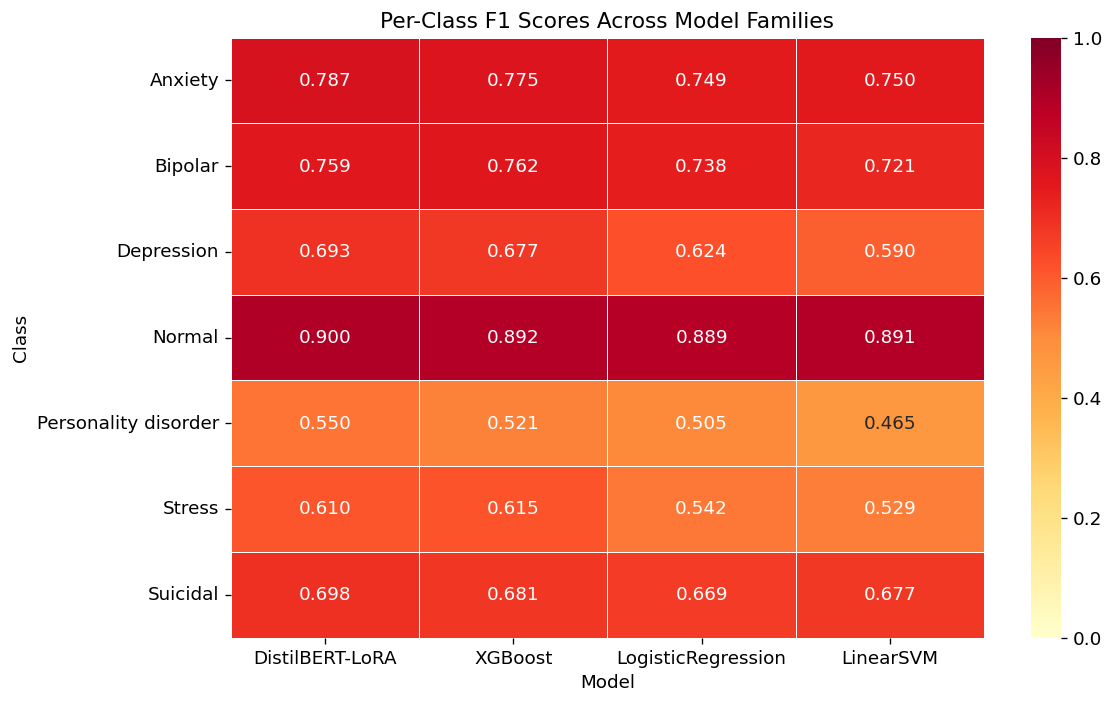

In [27]:
# ============================================================
# CELL 25 — Per-Class F1 Heatmap (All Models)
# ------------------------------------------------------------
# If XGBoost is loaded, we show a heatmap with rows = classes,
# columns = models. For EXP-1 and EXP-2, we attempt to reload
# models from disk; if unavailable, we show only BERT + XGBoost.
# ============================================================

# Collect per-class F1 for each model we can evaluate
heatmap_data = {}
heatmap_data['DistilBERT-LoRA'] = bert_per_class_f1

if xgb_loaded:
    heatmap_data['XGBoost'] = xgb_per_class_f1

# Try to load best LR and SVM models for per-class F1
for model_file, model_name, exp_name in [
    ('lr_class_weighted.joblib', 'LogisticRegression', 'EXP-1'),
    ('lr_smote.joblib', 'LogisticRegression', 'EXP-1'),
    ('lr_no_balancing.joblib', 'LogisticRegression', 'EXP-1'),
    ('svm_class_weighted.joblib', 'LinearSVM', 'EXP-2'),
    ('svm_smote.joblib', 'LinearSVM', 'EXP-2'),
    ('svm_no_balancing.joblib', 'LinearSVM', 'EXP-2'),
]:
    # Skip if we already have a model from this family
    if model_name in heatmap_data:
        continue

    model_path = MODELS_DIR / model_file
    if model_path.exists():
        try:
            loaded_model = joblib.load(model_path)
            # These classical models use TF-IDF features
            y_pred_loaded = loaded_model.predict(X_test_tfidf)
            per_class_f1_loaded = f1_score(y_test, y_pred_loaded, average=None, zero_division=0).tolist()
            heatmap_data[model_name] = per_class_f1_loaded
            print(f'Loaded {model_file} for per-class F1')
        except Exception as e:
            print(f'Could not load {model_file}: {e}')

# Build heatmap dataframe
heatmap_df = pd.DataFrame(heatmap_data, index=CLASS_NAMES)

print(f'\nPer-Class F1 Heatmap Data ({len(heatmap_df.columns)} models):')
print(heatmap_df.round(4).to_string())

# Plot heatmap
fig, ax = plt.subplots(figsize=(max(8, len(heatmap_df.columns) * 2.5), 6))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title('Per-Class F1 Scores Across Model Families', fontsize=13)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Class', fontsize=11)
plt.tight_layout()

fig.savefig(FIGURES_DIR / 'per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
print(f'\nSaved: {FIGURES_DIR / "per_class_f1_heatmap.png"}')
plt.show()

---

## 9. Statistical Significance — McNemar's Test

McNemar's test compares two classifiers by examining their **disagreement patterns**.
It answers: _"Are the two models making errors on significantly different subsets of samples?"_

The test uses a 2x2 contingency table:
- `b` = samples that Model A got right and Model B got wrong
- `c` = samples that Model B got right and Model A got wrong

If `b` and `c` are significantly different, the models have genuinely different
error patterns (not just random variation).

**Null hypothesis:** Both models have the same error rate (b = c).  
**Alternative:** The models differ significantly (reject if p < 0.05).

In [28]:
# ============================================================
# CELL 26 — McNemar's Test: DistilBERT vs XGBoost
# ============================================================

if xgb_loaded:
    from scipy.stats import binomtest, chi2

    # Build contingency table
    bert_correct = (y_pred_bert == y_test)
    xgb_correct  = (y_pred_xgb == y_test)

    # 2x2 contingency table
    both_correct  = np.sum(bert_correct & xgb_correct)
    both_wrong    = np.sum(~bert_correct & ~xgb_correct)
    bert_only     = np.sum(bert_correct & ~xgb_correct)   # b: BERT right, XGB wrong
    xgb_only      = np.sum(~bert_correct & xgb_correct)   # c: XGB right, BERT wrong

    print('McNemar\'s Test: DistilBERT-LoRA vs XGBoost')
    print('=' * 60)
    print(f'\n  Contingency Table:')
    print(f'  {"":>25} {"XGBoost Correct":>16} {"XGBoost Wrong":>14}')
    print(f'  {"BERT Correct":>25} {both_correct:>16} {bert_only:>14}')
    print(f'  {"BERT Wrong":>25} {xgb_only:>16} {both_wrong:>14}')
    print()
    print(f'  b (BERT right, XGB wrong) = {bert_only}')
    print(f'  c (XGB right, BERT wrong) = {xgb_only}')
    print()

    # McNemar's test (exact binomial test when b+c < 25, chi-squared otherwise)
    n_discordant = bert_only + xgb_only

    if n_discordant > 0:
        if n_discordant < 25:
            # Exact binomial test (more appropriate for small samples)
            # Under H0: P(BERT right | discordant) = 0.5
            result = binomtest(bert_only, n_discordant, 0.5)
            p_value = result.pvalue
            test_type = 'Exact binomial'
        else:
            # Chi-squared approximation with continuity correction
            chi2_stat = (abs(bert_only - xgb_only) - 1)**2 / (bert_only + xgb_only)
            p_value = 1 - chi2.cdf(chi2_stat, df=1)
            test_type = f'Chi-squared (stat={chi2_stat:.4f})'

        print(f'  Test type: {test_type}')
        print(f'  p-value: {p_value:.6f}')
        print()

        alpha = 0.05
        if p_value < alpha:
            print(f'  RESULT: Significant difference (p < {alpha})')
            print(f'  The two models have genuinely different error patterns.')
            if bert_only > xgb_only:
                print(f'  DistilBERT makes fewer errors on the disagreement set.')
            else:
                print(f'  XGBoost makes fewer errors on the disagreement set.')
        else:
            print(f'  RESULT: No significant difference (p = {p_value:.4f} >= {alpha})')
            print(f'  Cannot conclude the models have different error rates.')
    else:
        print('  Both models agree on all samples — no discordant pairs.')

    print()
    print(f'  Overall agreement: {(both_correct + both_wrong) / len(y_test):.1%} of test samples')
    print(f'  Discordant pairs : {n_discordant} ({n_discordant/len(y_test):.1%} of test samples)')

else:
    print('Skipped: XGBoost predictions not available for McNemar\'s test.')

McNemar's Test: DistilBERT-LoRA vs XGBoost

  Contingency Table:
                             XGBoost Correct  XGBoost Wrong
               BERT Correct             7058            927
                 BERT Wrong              803           1749

  b (BERT right, XGB wrong) = 927
  c (XGB right, BERT wrong) = 803

  Test type: Chi-squared (stat=8.7451)
  p-value: 0.003104

  RESULT: Significant difference (p < 0.05)
  The two models have genuinely different error patterns.
  DistilBERT makes fewer errors on the disagreement set.

  Overall agreement: 83.6% of test samples
  Discordant pairs : 1730 (16.4% of test samples)


Saved: /content/drive/MyDrive/Guna_CMPE255_Project_Final/figures/error_pattern_analysis.png


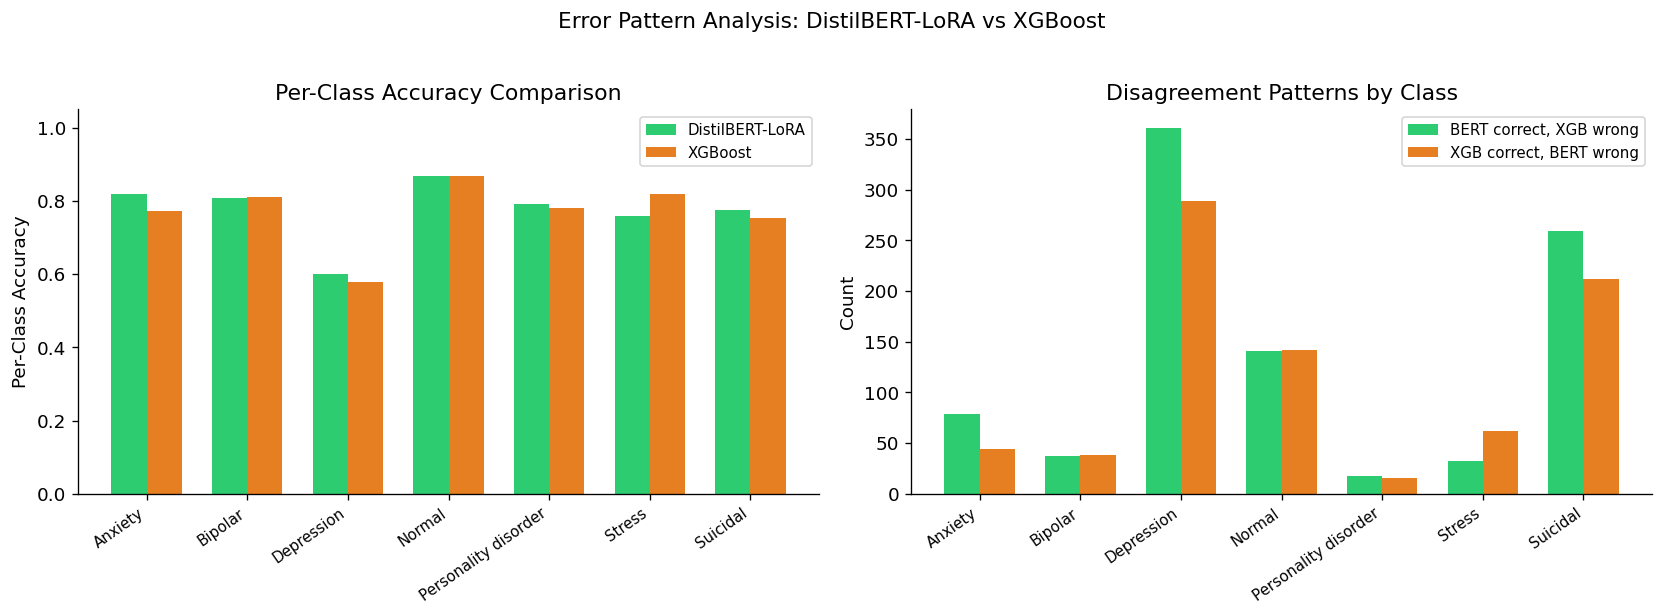

In [29]:
# ============================================================
# CELL 27 — Error Pattern Visualization
# ============================================================

if xgb_loaded:
    # Visualize where each model fails
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Per-class accuracy for each model
    bert_per_class_acc = []
    xgb_per_class_acc = []

    for i in range(NUM_CLASSES):
        mask = (y_test == i)
        bert_per_class_acc.append(np.mean(y_pred_bert[mask] == y_test[mask]))
        xgb_per_class_acc.append(np.mean(y_pred_xgb[mask] == y_test[mask]))

    # Left plot: per-class accuracy comparison
    x = np.arange(NUM_CLASSES)
    width = 0.35
    axes[0].bar(x - width/2, bert_per_class_acc, width,
               label='DistilBERT-LoRA', color='#2ECC71')
    axes[0].bar(x + width/2, xgb_per_class_acc, width,
               label='XGBoost', color='#E67E22')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=9)
    axes[0].set_ylabel('Per-Class Accuracy')
    axes[0].set_title('Per-Class Accuracy Comparison')
    axes[0].legend(fontsize=9)
    axes[0].set_ylim(0, 1.05)

    # Right plot: disagreement analysis by class
    bert_only_per_class = []
    xgb_only_per_class = []
    for i in range(NUM_CLASSES):
        mask = (y_test == i)
        bert_only_per_class.append(np.sum(bert_correct[mask] & ~xgb_correct[mask]))
        xgb_only_per_class.append(np.sum(~bert_correct[mask] & xgb_correct[mask]))

    axes[1].bar(x - width/2, bert_only_per_class, width,
               label='BERT correct, XGB wrong', color='#2ECC71')
    axes[1].bar(x + width/2, xgb_only_per_class, width,
               label='XGB correct, BERT wrong', color='#E67E22')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=9)
    axes[1].set_ylabel('Count')
    axes[1].set_title('Disagreement Patterns by Class')
    axes[1].legend(fontsize=9)

    plt.suptitle('Error Pattern Analysis: DistilBERT-LoRA vs XGBoost', fontsize=13, y=1.02)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'error_pattern_analysis.png', dpi=150, bbox_inches='tight')
    print(f'Saved: {FIGURES_DIR / "error_pattern_analysis.png"}')
    plt.show()
else:
    print('Skipped: XGBoost predictions not available.')

---

## 10. Final Summary & Deployment Recommendation

This section provides the definitive ranking of all model families and
a deployment recommendation for the CMPE-255 project report.

In [30]:
# ============================================================
# CELL 28 — Final Ranking & Recommendation
# ============================================================

print('\n' + '=' * 80)
print('  FINAL MODEL RANKING — Mental Health & Crisis Signal Mining')
print('  CMPE-255 Data Mining Project')
print('=' * 80)
print()

# Build final ranking
ranking = best_models[['exp_name', 'model', 'condition', 'macro_f1',
                        'weighted_f1', 'roc_auc_macro', 'accuracy']].copy()
ranking = ranking.sort_values('macro_f1', ascending=False).reset_index(drop=True)
ranking.insert(0, 'Rank', range(1, len(ranking) + 1))

print(ranking.to_string(index=False))

# Identify the best model
best_row = ranking.iloc[0]

print(f'\n{"="*80}')
print(f'  WINNER: {best_row["model"]} ({best_row["condition"]})')
print(f'  Macro-F1 = {best_row["macro_f1"]:.4f}')
print(f'{"="*80}')
print()

# Deployment recommendation
print('DEPLOYMENT RECOMMENDATION')
print('-' * 40)
print()

if best_row['model'] == 'DistilBERT-LoRA':
    print('  Recommended model: DistilBERT + LoRA')
    print()
    print('  Strengths:')
    print('  - Highest macro-F1 across all model families')
    print('  - Leverages contextual understanding from pretraining')
    print('  - Better at disambiguating semantically similar classes')
    print('    (Anxiety vs Stress, Depression vs Suicidal)')
    print('  - LoRA makes fine-tuning efficient (few trainable params)')
    print()
    print('  Considerations:')
    print('  - Requires GPU for real-time inference (or batched CPU)')
    print('  - Higher latency than XGBoost for single predictions')
    print('  - Model size: ~67M parameters (DistilBERT base)')
    print()
    print('  Fallback: XGBoost is recommended if:')
    print('  - Real-time latency is critical (< 10ms per prediction)')
    print('  - No GPU is available in production')
    print('  - Model interpretability is a hard requirement (SHAP)')
elif best_row['model'] == 'XGBoost':
    print('  Recommended model: XGBoost (Bayesian-tuned)')
    print()
    print('  Strengths:')
    print('  - Highest macro-F1 across all model families')
    print('  - Fast inference (< 5ms per prediction on CPU)')
    print('  - Highly interpretable via SHAP / feature importance')
    print('  - Combines multiple feature types effectively')
    print()
    print('  Considerations:')
    print('  - Requires feature engineering pipeline (TF-IDF + NRC + LDA)')
    print('  - May miss nuanced contextual cues that transformers capture')
    print()
    print('  Alternative: DistilBERT-LoRA if:')
    print('  - GPU is available in production')
    print('  - Higher accuracy on ambiguous cases is needed')
else:
    print(f'  Recommended model: {best_row["model"]} ({best_row["condition"]})')
    print(f'  Achieved the highest macro-F1 of {best_row["macro_f1"]:.4f}')


  FINAL MODEL RANKING — Mental Health & Crisis Signal Mining
  CMPE-255 Data Mining Project

 Rank exp_name              model            condition  macro_f1  weighted_f1  roc_auc_macro  accuracy
    1    EXP-4    DistilBERT-LoRA            finetuned    0.7139       0.7617         0.9628    0.7578
    2    EXP-3            XGBoost tfidf+engineered+lda    0.7033       0.7500         0.9582    0.7460
    3    EXP-1 LogisticRegression         no_balancing    0.6740       0.7242         0.9466    0.7223
    4    EXP-2          LinearSVM         no_balancing    0.6605       0.7141         0.9419    0.7129

  WINNER: DistilBERT-LoRA (finetuned)
  Macro-F1 = 0.7139

DEPLOYMENT RECOMMENDATION
----------------------------------------

  Recommended model: DistilBERT + LoRA

  Strengths:
  - Highest macro-F1 across all model families
  - Leverages contextual understanding from pretraining
  - Better at disambiguating semantically similar classes
    (Anxiety vs Stress, Depression vs Suicidal)
 

In [31]:
# ============================================================
# CELL 29 — Key Findings Summary
# ============================================================

print('\n' + '=' * 80)
print('  KEY FINDINGS FOR REPORT')
print('=' * 80)
print()

print('1. MODEL HIERARCHY:')
for _, row in ranking.iterrows():
    print(f'   #{int(row["Rank"])}: {row["model"]:20s} | macro-F1 = {row["macro_f1"]:.4f}')

print()
print('2. CONTEXTUAL vs LEXICAL:')
if xgb_loaded:
    bert_f1 = metrics_bert['macro_f1']
    xgb_f1 = metrics_xgb['macro_f1']
    diff = bert_f1 - xgb_f1
    if diff > 0:
        print(f'   DistilBERT outperforms XGBoost by {diff:.4f} macro-F1 points.')
        print(f'   Contextual embeddings provide meaningful gains over TF-IDF features.')
    elif diff < 0:
        print(f'   XGBoost outperforms DistilBERT by {-diff:.4f} macro-F1 points.')
        print(f'   Well-engineered features + boosting remain competitive.')
    else:
        print(f'   Both models achieve identical macro-F1 ({bert_f1:.4f}).')

print()
print('3. CLASS-LEVEL INSIGHTS:')
if xgb_loaded:
    # Find hardest class for both models
    avg_f1_per_class = [(bert_per_class_f1[i] + xgb_per_class_f1[i]) / 2
                        for i in range(NUM_CLASSES)]
    hardest_idx = np.argmin(avg_f1_per_class)
    easiest_idx = np.argmax(avg_f1_per_class)
    print(f'   Hardest class: {CLASS_NAMES[hardest_idx]} (avg F1 = {avg_f1_per_class[hardest_idx]:.4f})')
    print(f'   Easiest class: {CLASS_NAMES[easiest_idx]} (avg F1 = {avg_f1_per_class[easiest_idx]:.4f})')

    # Where BERT excels most
    diffs = [b - x for b, x in zip(bert_per_class_f1, xgb_per_class_f1)]
    bert_best_class = CLASS_NAMES[np.argmax(diffs)]
    xgb_best_class = CLASS_NAMES[np.argmin(diffs)]
    print(f'   DistilBERT advantage largest on: {bert_best_class} (+{max(diffs):.4f})')
    print(f'   XGBoost advantage largest on: {xgb_best_class} (+{-min(diffs):.4f})')

print()
print('4. LEAKAGE VALIDATION:')
if 'LP-Probe' in all_metrics['exp_name'].values:
    lp_f1 = all_metrics[all_metrics['exp_name'] == 'LP-Probe']['macro_f1'].values[0]
    print(f'   LP-Probe macro-F1 = {lp_f1:.4f} (surface stats only)')
    if lp_f1 < 0.40:
        print(f'   PASS: Models are learning genuine mental health signals, not formatting artifacts.')
    else:
        print(f'   WARNING: Some surface leakage may be inflating results.')
else:
    print('   LP-Probe not found in metrics.csv (run NB-04 first).')

print()
print('5. STATISTICAL SIGNIFICANCE:')
if xgb_loaded and n_discordant > 0:
    print(f'   McNemar\'s test p-value = {p_value:.6f}')
    if p_value < 0.05:
        print(f'   The difference between DistilBERT and XGBoost IS statistically significant.')
    else:
        print(f'   The difference is NOT statistically significant (p >= 0.05).')

print()
print('=' * 80)
print('  Notebook 08 complete.')
print(f'  Results saved to: {METRICS_CSV}')
print(f'  Figures saved to: {FIGURES_DIR}')
print('=' * 80)


  KEY FINDINGS FOR REPORT

1. MODEL HIERARCHY:
   #1: DistilBERT-LoRA      | macro-F1 = 0.7139
   #2: XGBoost              | macro-F1 = 0.7033
   #3: LogisticRegression   | macro-F1 = 0.6740
   #4: LinearSVM            | macro-F1 = 0.6605

2. CONTEXTUAL vs LEXICAL:
   DistilBERT outperforms XGBoost by 0.0106 macro-F1 points.
   Contextual embeddings provide meaningful gains over TF-IDF features.

3. CLASS-LEVEL INSIGHTS:
   Hardest class: Personality disorder (avg F1 = 0.5355)
   Easiest class: Normal (avg F1 = 0.8961)
   DistilBERT advantage largest on: Personality disorder (+0.0292)
   XGBoost advantage largest on: Stress (+0.0050)

4. LEAKAGE VALIDATION:
   LP-Probe macro-F1 = 0.3049 (surface stats only)
   PASS: Models are learning genuine mental health signals, not formatting artifacts.

5. STATISTICAL SIGNIFICANCE:
   McNemar's test p-value = 0.003104
   The difference between DistilBERT and XGBoost IS statistically significant.

  Notebook 08 complete.
  Results saved to: /cont